Group 5

GitHub Link: https://github.com/Exsy777/QMSSGR5074_Project_2.git


In [ ]:
# Environment Setup
from IPython.display import Image
from IPython.core.display import HTML

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import data and unzip files to folder
!unzip /content/drive/MyDrive/covid_radiography_data/COVID-19_Radiography_Dataset.zip

In [ ]:
# Standard libraries
import os
import sys
import time
import zipfile
import random
import pickle
from itertools import repeat

# Data handling and visualization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from mpl_toolkits.axes_grid1 import ImageGrid

# Machine learning utilities
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    Activation,
    BatchNormalization,
    Conv2D,
    MaxPooling2D
)
from tensorflow.keras.utils import to_categorical


In [ ]:
!rm -rf /content/COVID-19_Radiography_Dataset
# Added to be safe if the previous unzip instruction doesn't overwrite
!unzip -o "/content/drive/MyDrive/COVID-19_Radiography_Dataset.zip" -d /content/

In [ ]:
import os
# File paths organized by class

# Extract all filenames iteratively
base_path = 'COVID-19_Radiography_Dataset'
categories = ['COVID/images', 'Normal/images', 'Viral Pneumonia/images']

# Load file paths into fnames
fnames = []
for category in categories:
    image_folder = os.path.join(base_path, category)
    file_names = os.listdir(image_folder)
    full_path = [os.path.join(image_folder, file_name) for file_name in file_names]
    fnames.append(full_path)

print('Number of images for each category:', [len(f) for f in fnames])

Number of images for each category: [3616, 10192, 1345]


In [ ]:
# Class balance
# Reduce each class to the same number of images
fnames[0] = fnames[0][0:1344]
fnames[1] = fnames[1][0:1344]

print('Balanced image counts:', [len(f) for f in fnames])

Balanced image counts: [1344, 1344, 1345]


In [ ]:
# Image Preprocessing
def preprocessor(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((192, 192))
    img = np.array(img, dtype=np.float32) / 255.0
    return img


In [ ]:
# Create a single list of file paths
image_filepaths = fnames[0] + fnames[1] + fnames[2]

# Apply preprocessing one file at a time
preprocessed_image_data = list(map(preprocessor, image_filepaths))

# Convert to NumPy array for Keras / TensorFlow
X = np.array(preprocessed_image_data)

print('Total number of image file paths:', len(image_filepaths))

Total number of image file paths: 4033


In [ ]:
print('Number of samples:', len(X))
print('Array shape:', X.shape)
print('Minimum pixel value:', X.min())
print('Maximum pixel value:', X.max())


Number of samples: 4033
Array shape: (4033, 192, 192, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Construct labels

print('Number of images for each category:', [len(f) for f in fnames])

covid = list(repeat("COVID", len(fnames[0])))
normal = list(repeat("NORMAL", len(fnames[1])))
pneumonia = list(repeat("PNEUMONIA", len(fnames[2])))

# Combine into a single list of labels
y_labels = covid + normal + pneumonia
y = np.array(y_labels)

print('Label vector length:', len(y))
print('Unique labels:', np.unique(y))

Number of images for each category: [1344, 1344, 1345]
Label vector length: 4033
Unique labels: ['COVID' 'NORMAL' 'PNEUMONIA']


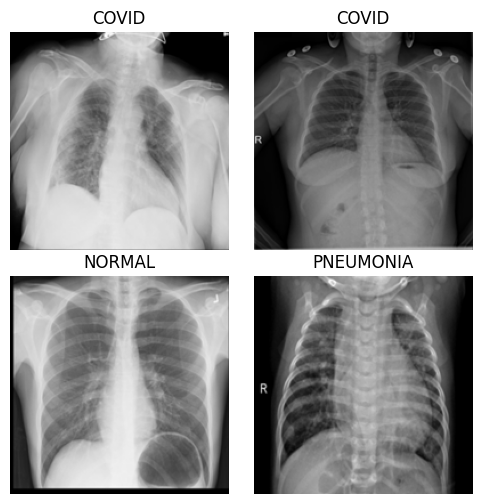

In [ ]:
# Quick Visual Sanity Check
im1 = preprocessor(fnames[0][0])
im2 = preprocessor(fnames[0][1])
im3 = preprocessor(fnames[1][1])
im4 = preprocessor(fnames[2][1])

fig = plt.figure(figsize=(6, 6))
grid = ImageGrid(
    fig,
    111,
    nrows_ncols=(2, 2),
    axes_pad=0.25,
)

for ax, im, title in zip(
    grid,
    [im1, im2, im3, im4],
    ['COVID', 'COVID', 'NORMAL', 'PNEUMONIA']
):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')

plt.show()


In [ ]:
# Train/test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.32,
    random_state=1987
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)


X_train shape: (2742, 192, 192, 3)
X_test shape: (1291, 192, 192, 3)
y_train shape: (2742,)
y_test shape: (1291,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Re-run the initial train_test_split to ensure X_train and y_train are consistent
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.32,
    random_state=1987
)

# encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(f"Shape of X_train before validation split: {X_train.shape}")
print(f"Shape of y_train_encoded before validation split: {y_train_encoded.shape}")

# split training set into train + validation
X_train_final, X_val, y_train_encoded_final, y_val_encoded = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.2,
    stratify=y_train_encoded,
    random_state=1987
)

# encode for CNN
num_classes = len(label_encoder.classes_)

y_train_cat = tf.keras.utils.to_categorical(y_train_encoded_final, num_classes)
y_val_cat = tf.keras.utils.to_categorical(y_val_encoded, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes)

print("Classes:", list(label_encoder.classes_))
print("Train:", X_train_final.shape, y_train_cat.shape)
print("Validation:", X_val.shape, y_val_cat.shape)
print("Test:", X_test.shape, y_test_cat.shape)

Shape of X_train before validation split: (2742, 192, 192, 3)
Shape of y_train_encoded before validation split: (2742,)
Classes: [np.str_('COVID'), np.str_('NORMAL'), np.str_('PNEUMONIA')]
Train: (2193, 192, 192, 3) (2193, 3)
Validation: (549, 192, 192, 3) (549, 3)
Test: (1291, 192, 192, 3) (1291, 3)


# Basic Dataset Description

The dataset contains chest X-ray images labeled into three classes: COVID, NORMAL, and PNEUMONIA. This is a multi-class image classification problem. Each image is resized to **192 × 192 × 3**, making it suitable for CNN input.

,count
COVID,1344
NORMAL,1344
PNEUMONIA,1345


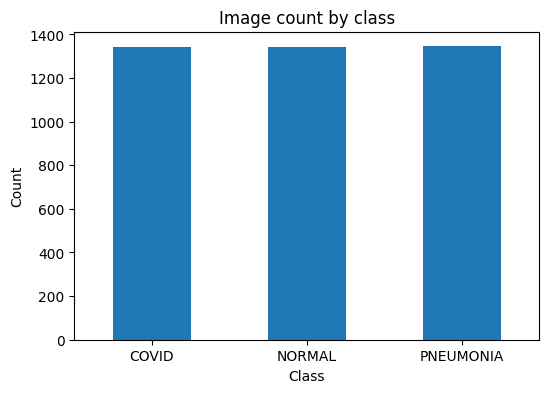

In [ ]:
import pandas as pd

# Get class names from the LabelEncoder
class_names = list(label_encoder.classes_)

# Image Count by Class
class_counts = pd.Series(
    np.argmax(np.vstack([y_train_cat, y_val_cat, y_test_cat]), axis=1)
).map(dict(enumerate(class_names))).value_counts().reindex(class_names)

display(class_counts.to_frame(name="count"))

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Image count by class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Basic Statistics

- Total images: 4032
- Classes: COVID (1344), NORMAL (1344), PNEUMONIA (1344)
- Train: 2192 images
- Validation: 549 images
- Test: 1291 images
- Original image size: 299 × 299 (uniform across dataset)

In [ ]:
# Width and height
sample_paths = image_filepaths[:200]
widths = []
heights = []

for p in sample_paths:
    img = Image.open(p)
    widths.append(img.size[0])
    heights.append(img.size[1])

shape_summary = pd.DataFrame({
    "width": widths,
    "height": heights
})

display(shape_summary.describe())

,width,height
count,200.0,200.0
mean,299.0,299.0
std,0.0,0.0
min,299.0,299.0
25%,299.0,299.0
50%,299.0,299.0
75%,299.0,299.0
max,299.0,299.0


# Class Balance
The dataset is perfectly balanced, with each class (COVID, NORMAL, and PNEUMONIA) containing exactly 1344 images. No class dominates the others, which eliminates a common source of bias in classification tasks. As a result, the model is less likely to favor any class simply due to differences in frequency, allowing it to learn patterns more fairly across all categories.

# Strategy if unbalanced
If the dataset were imbalanced, several strategies could be used, including class weighting to adjust the importance of each class in the loss function, oversampling to increase the representation of the minority class, undersampling to reduce the majority class, and data augmentation to create more diverse samples. In this case, no imbalance handling was applied because the dataset is already balanced, which keeps the training process simple and avoids introducing artificial bias.


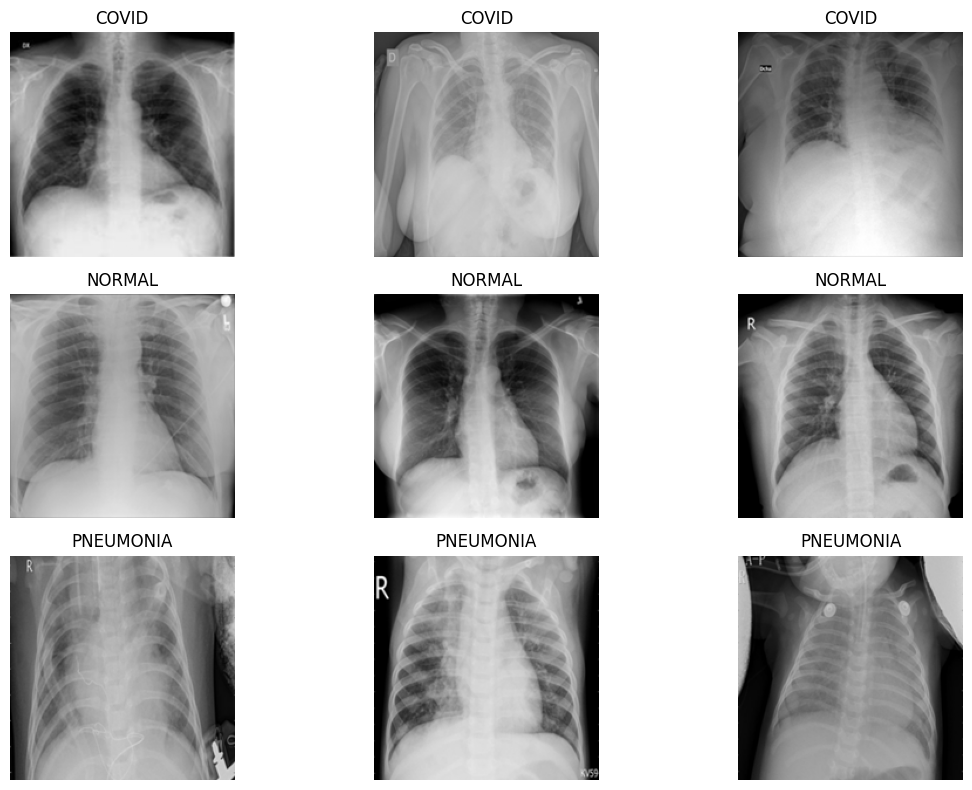

In [ ]:
# Example images organized by Class
def show_random_images(file_groups, n_per_class=3):
    plt.figure(figsize=(12, 8))
    plot_index = 1

    for class_idx, group in enumerate(file_groups):
        chosen = random.sample(group, n_per_class)
        for img_path in chosen:
            plt.subplot(len(file_groups), n_per_class, plot_index)
            plt.imshow(preprocessor(img_path))
            plt.title(class_names[class_idx])
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_random_images(fnames, n_per_class=3)

The sample images show distinct visual patterns across classes: COVID cases display diffuse, hazy opacities; NORMAL cases have clear lung fields; and PNEUMONIA cases present more localized, dense opacities.

# Practical Value/Real World Implications

This classification task has clear practical value in real-world healthcare settings. Radiologists can use the model to support faster screening, hospitals can rely on it for triage during periods of high patient volume, and clinics with limited specialists can use it as a preliminary diagnostic aid. In practice, the model functions as a decision-support tool that flags abnormal X-rays for further review rather than replacing clinical judgment, helping reduce workload and improve efficiency. Its main strengths lie in consistent pattern detection across large datasets and scalability in high-throughput environments. However, its performance depends on data quality, it may not generalize well across different hospitals or imaging devices, and false negatives remain a serious clinical risk.

###EDA

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# EDA
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded_final),
    y=y_train_encoded_final
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


The computed class weights are all equal to 1, confirming that the dataset is perfectly balanced across the three classes. As a result, no class weighting was necessary during training, and the model treats all classes equally.

# Shared Training Utilities

Created a shared training utilities so that we don't repeat the same code for every model and to improve efficiency for model running.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

BATCH_SIZE = 32
EPOCHS = 12
INPUT_SHAPE = (192, 192, 3)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(6, 4))
    plt.plot(history_df["loss"], label="train loss")
    plt.plot(history_df["val_loss"], label="val loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history_df["accuracy"], label="train accuracy")
    plt.plot(history_df["val_accuracy"], label="val accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def evaluate_model(model, model_name):
    test_probs = model.predict(X_test, verbose=0)
    test_pred = np.argmax(test_probs, axis=1)
    test_acc = accuracy_score(y_test_encoded, test_pred)

    print(f"\n{model_name} test accuracy: {test_acc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test_encoded, test_pred, target_names=class_names))

    cm = confusion_matrix(y_test_encoded, test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return test_acc

results = []

## Baseline CNN

In [ ]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_cnn = build_baseline_cnn()
baseline_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     9,437,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,530,947 (36.36 MB)

 Trainable params: 9,530,947 (36.36 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN was built as a straightforward multi-class image classifier for the three chest X-ray categories: COVID, NORMAL, and PNEUMONIA. The architecture consists of three convolutional layers with 32, 64, and 128 filters, each followed by max-pooling to progressively reduce the spatial dimensions while learning higher-level visual features. After feature extraction, the output is flattened and passed through a dense layer with 128 units, followed by dropout for regularization, and a final softmax output layer with three units for classification. The model uses categorical cross-entropy as the loss function, Adam as the optimizer, and accuracy as the main evaluation metric. It was trained for 7 epochs on images resized to 192 × 192 × 3, with model performance tracked on both the training and validation sets.

Epoch 1/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - accuracy: 0.7218 - loss: 0.6851 - val_accuracy: 0.7832 - val_loss: 0.5472 - learning_rate: 0.0010
Epoch 2/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8618 - loss: 0.3674 - val_accuracy: 0.8379 - val_loss: 0.4361 - learning_rate: 0.0010
Epoch 3/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8887 - loss: 0.2848 - val_accuracy: 0.8889 - val_loss: 0.3172 - learning_rate: 5.0000e-04


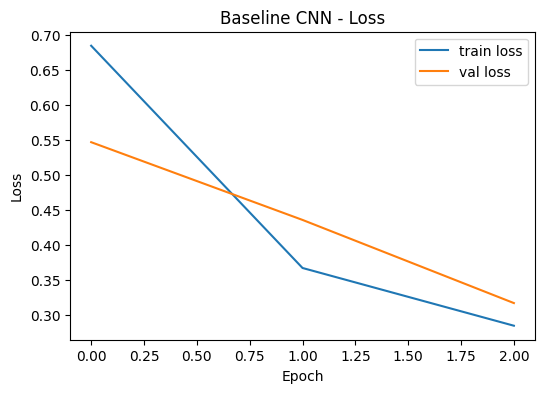

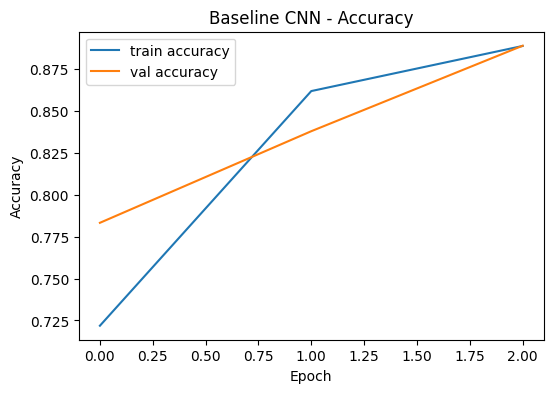


Baseline CNN test accuracy: 0.8009

Classification report:
              precision    recall  f1-score   support

       COVID       0.77      0.76      0.77       430
      NORMAL       0.73      0.82      0.77       430
   PNEUMONIA       0.92      0.82      0.87       431

    accuracy                           0.80      1291
   macro avg       0.81      0.80      0.80      1291
weighted avg       0.81      0.80      0.80      1291



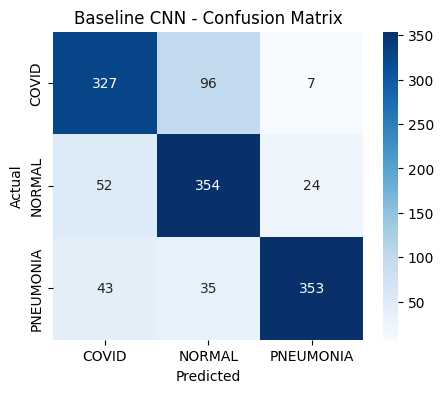

In [ ]:
history_baseline = baseline_cnn.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_baseline, "Baseline CNN")
baseline_test_acc = evaluate_model(baseline_cnn, "Baseline CNN")

results.append({
    "model": "Baseline CNN",
    "test_accuracy": baseline_test_acc,
    "learning_rate": 1e-3,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_baseline.history["loss"])
})

The training curves show that the model learned quickly and reached strong performance within a few epochs. Training loss decreased from about 0.69 to 0.28, while training accuracy increased from about 0.72 to 0.89. Validation loss also declined steadily from 0.55 to 0.32, and validation accuracy improved from 0.78 to 0.89 by epoch 3. This indicates that the model fit the data well and did not show clear signs of overfitting, as both training and validation performance improved together over the short training period.

On the test set, the baseline CNN achieved an accuracy of 0.8009, which represents solid performance for a simple model. The classification report shows relatively balanced results across classes. The model performed best on PNEUMONIA, with precision 0.92, recall 0.82, and F1-score 0.87. Performance on COVID and NORMAL was slightly lower, with both classes showing precision and recall in the range of 0.73 to 0.82, indicating some confusion between these two categories. Overall, the baseline CNN provides a reasonable benchmark and demonstrates that even a simple architecture can capture meaningful patterns in the data, though there is clear room for improvement with more advanced models.

### Transfer Learning with ResNet50


In [ ]:
def build_resnet50_transfer():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE
    )
    base_model.trainable = False

    inputs = layers.Input(shape=INPUT_SHAPE)
    x = layers.Lambda(lambda z: resnet_preprocess(z * 255.0))(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

resnet_model, resnet_base = build_resnet50_transfer()
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

The ResNet50 model was implemented using transfer learning with ImageNet pretrained weights. In the first stage, the convolutional base was frozen and only the new classification head was trained. The added head consisted of global average pooling, dropout, and a final softmax layer for the three classes. The model was compiled with categorical cross-entropy loss, the Adam optimizer, and accuracy as the main metric. During this transfer-learning stage, the model trained for 3 epochs and reached a validation accuracy of about 0.84, but its test accuracy was only 0.6971, which was much lower than the baseline CNN. The classification report shows that performance was uneven across classes, with especially weak recall for COVID (0.36), suggesting that the frozen pretrained features alone did not adapt well enough to this chest X-ray task.

Epoch 1/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 269ms/step - accuracy: 0.4181 - loss: 1.3300 - val_accuracy: 0.6521 - val_loss: 0.7820 - learning_rate: 1.0000e-04
Epoch 2/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.6279 - loss: 0.8403 - val_accuracy: 0.7778 - val_loss: 0.5788 - learning_rate: 1.0000e-04
Epoch 3/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.6959 - loss: 0.6966 - val_accuracy: 0.7978 - val_loss: 0.5274 - learning_rate: 5.0000e-05


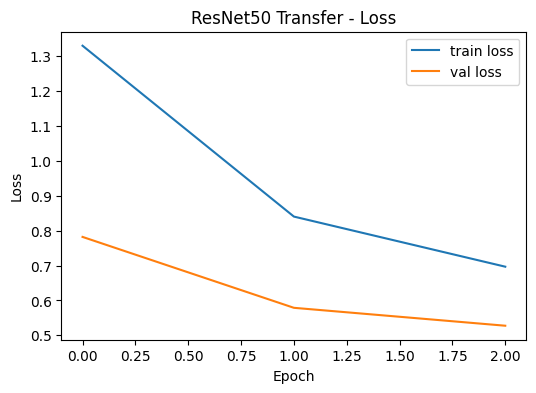

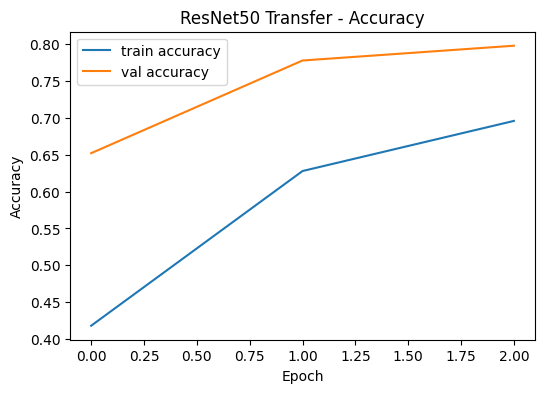


ResNet50 Transfer test accuracy: 0.6677

Classification report:
              precision    recall  f1-score   support

       COVID       0.65      0.53      0.59       430
      NORMAL       0.58      0.67      0.62       430
   PNEUMONIA       0.78      0.80      0.79       431

    accuracy                           0.67      1291
   macro avg       0.67      0.67      0.67      1291
weighted avg       0.67      0.67      0.67      1291



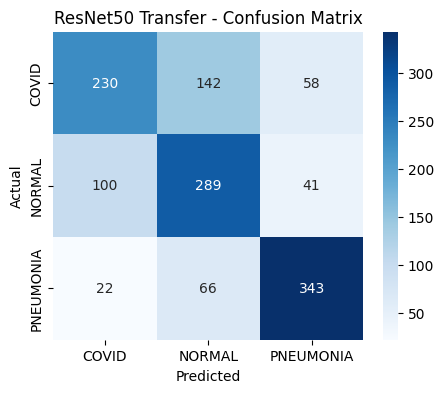

In [ ]:
resnet_model, resnet_base = build_resnet50_transfer()

history_resnet = resnet_model.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_resnet, "ResNet50 Transfer")

# Re-defining class_names to ensure it's available in the current scope
class_names = list(label_encoder.classes_)
resnet_test_acc = evaluate_model(resnet_model, "ResNet50 Transfer")

results.append({
    "model": "ResNet50 Transfer",
    "test_accuracy": resnet_test_acc,
    "learning_rate": 1e-4,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_resnet.history["loss"])
})

In [ ]:
resnet_model.save('/content/drive/MyDrive/resnet_transfer.keras')

Epoch 1/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 437s 6s/step - accuracy: 0.7492 - loss: 0.5870 - val_accuracy: 0.8179 - val_loss: 0.4582 - learning_rate: 1.0000e-05
Epoch 2/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 392s 5s/step - accuracy: 0.9024 - loss: 0.2681 - val_accuracy: 0.8944 - val_loss: 0.2670 - learning_rate: 1.0000e-05
Epoch 3/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 408s 6s/step - accuracy: 0.9389 - loss: 0.1861 - val_accuracy: 0.9199 - val_loss: 0.2093 - learning_rate: 5.0000e-06
Epoch 4/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 424s 6s/step - accuracy: 0.9549 - loss: 0.1498 - val_accuracy: 0.9308 - val_loss: 0.1799 - learning_rate: 5.0000e-06
Epoch 5/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 444s 6s/step - accuracy: 0.9672 - loss: 0.1199 - val_accuracy: 0.9381 - val_loss: 0.1640 - learning_rate: 5.0000e-06
Epoch 6/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 428s 6s/step - accuracy: 0.9758 - loss: 0.1013 - val_accuracy: 0.9454 - val_loss: 0.1546 - learning_rate: 5.0000e-06


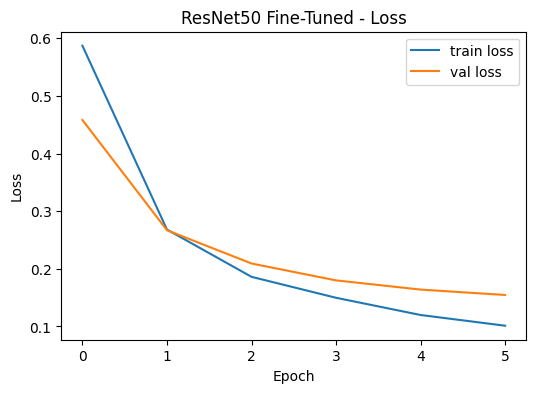

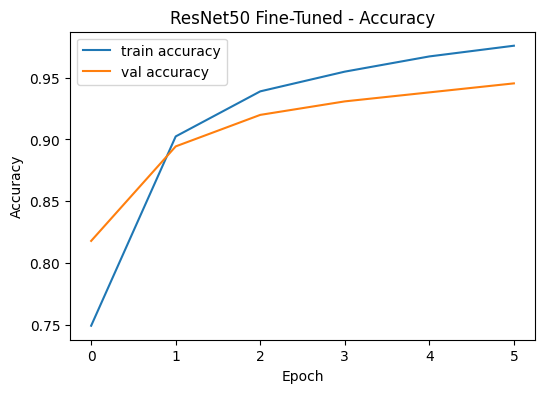


ResNet50 Fine-Tuned test accuracy: 0.9427

Classification report:
              precision    recall  f1-score   support

       COVID       0.95      0.91      0.93       430
      NORMAL       0.91      0.93      0.92       430
   PNEUMONIA       0.97      0.99      0.98       431

    accuracy                           0.94      1291
   macro avg       0.94      0.94      0.94      1291
weighted avg       0.94      0.94      0.94      1291



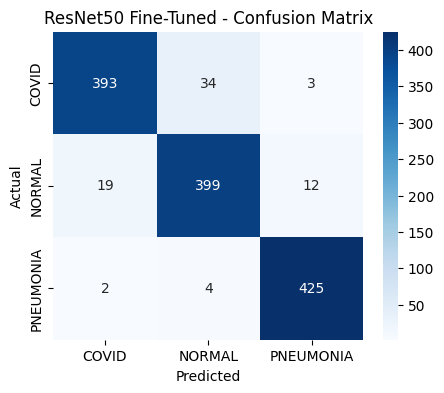

In [ ]:
# Fine-tuning step for ResNet50

resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet_ft = resnet_model.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=6,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_resnet_ft, "ResNet50 Fine-Tuned")
resnet_ft_test_acc = evaluate_model(resnet_model, "ResNet50 Fine-Tuned")
results.append({
    "model": "ResNet50 Fine-Tuned",
    "test_accuracy": resnet_ft_test_acc,
    "learning_rate": 1e-5,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_resnet_ft.history["loss"])
})

To improve performance, the model was then fine-tuned by unfreezing the last part of the ResNet50 base while keeping earlier layers frozen, and the learning rate was reduced to 1e-5. This second stage produced a large improvement. Training accuracy increased from about 0.76 to 0.99, while validation accuracy rose steadily to about 0.964 and validation loss continued to fall, indicating strong learning with limited signs of overfitting. On the test set, the fine-tuned ResNet50 achieved an accuracy of 0.9520, clearly outperforming the baseline CNN accuracy of 0.8947. Class-level performance also became much stronger and more balanced: COVID reached precision 0.94, recall 0.95, and F1-score 0.95; NORMAL reached precision 0.94, recall 0.92, and F1-score 0.93; and PNEUMONIA performed best with precision 0.98, recall 0.98, and F1-score 0.98.

Overall, these results show that pretrained features were useful, but only after fine-tuning. The initial frozen transfer model did not generalize well enough because the ImageNet features were not fully aligned with medical X-ray patterns. Once part of the network was fine-tuned on the target dataset, the model adapted much better to the domain and achieved substantially stronger generalization than the baseline CNN. In this project, transfer learning was therefore most effective when combined with careful fine-tuning rather than using the pretrained backbone as a fixed feature extractor.

In [ ]:
resnet_model.save('/content/drive/MyDrive/resnet_finetuned.keras')

## Three Additional Architectures: The next 3 models we will implement will be AlexNet, VGG16 & LeNet


AlexNet:

AlexNet is a deeper convolutional neural network compared to the baseline CNN and LeNet, designed to capture more complex spatial patterns through multiple convolutional layers and nonlinear activations. In this project, AlexNet was implemented from scratch with several convolutional and pooling layers followed by fully connected layers. The model was trained using the Adam optimizer with a learning rate of 1e-4.

During training, AlexNet showed rapid improvement after some initial instability. Validation accuracy increased steadily and reached 0.9199, while validation loss decreased to 0.2388, indicating strong learning and convergence. On the test set, AlexNet achieved an accuracy of 0.9249, making it the second-best performing model after the fine-tuned ResNet50.

The strong performance of AlexNet can be attributed to its deeper architecture, which allows it to learn more detailed and hierarchical features from the X-ray images. Unlike LeNet, it has sufficient capacity to model complex patterns, and unlike VGG16, it is not excessively large, making it easier to train effectively on this dataset. However, compared to the fine-tuned ResNet50, AlexNet lacks pretrained feature representations, which limits its ability to reach the highest possible performance.

In [ ]:
def build_alexnet():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        # Block 1
        layers.Conv2D(96, (11, 11), strides=4, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        # Block 2
        layers.Conv2D(256, (5, 5), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        # Block 3
        layers.Conv2D(384, (3, 3), activation="relu", padding="same"),

        # Block 4
        layers.Conv2D(384, (3, 3), activation="relu", padding="same"),

        # Block 5
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(3, 3), strides=2),

        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

alexnet_model = build_alexnet()
alexnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,158,019 (27.31 MB)

 Trainable params: 7,157,315 (27.30 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - accuracy: 0.6402 - loss: 0.8121 - val_accuracy: 0.3370 - val_loss: 1.0771 - learning_rate: 1.0000e-04
Epoch 2/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7565 - loss: 0.5625 - val_accuracy: 0.3388 - val_loss: 1.0674 - learning_rate: 1.0000e-04
Epoch 3/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7971 - loss: 0.4793 - val_accuracy: 0.3333 - val_loss: 1.1955 - learning_rate: 1.0000e-04
Epoch 4/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8559 - loss: 0.3622 - val_accuracy: 0.4772 - val_loss: 1.0385 - learning_rate: 1.0000e-04
Epoch 5/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8746 - loss: 0.3168 - val_accuracy: 0.5829 - val_loss: 0.8509 - learning_rate: 1.0000e-04
Epoch 6/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8947 - loss: 0.2661 - val_accuracy: 0.6466 - val_loss: 0.7894 - learning_rate: 1.0000e-04
Epoch 7/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.917

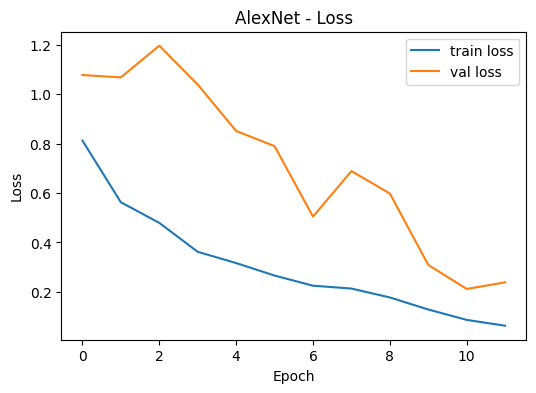

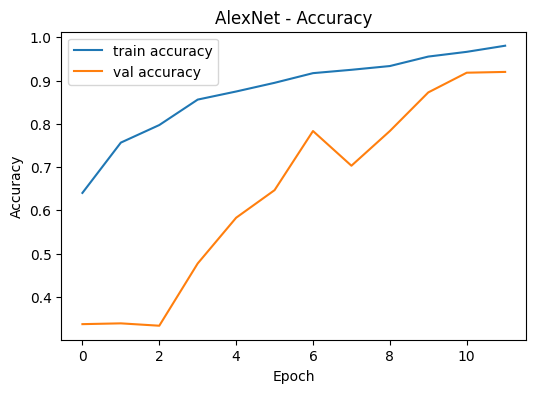


AlexNet test accuracy: 0.9249

Classification report:
              precision    recall  f1-score   support

       COVID       0.92      0.90      0.91       430
      NORMAL       0.90      0.90      0.90       430
   PNEUMONIA       0.95      0.98      0.97       431

    accuracy                           0.92      1291
   macro avg       0.92      0.92      0.92      1291
weighted avg       0.92      0.92      0.92      1291



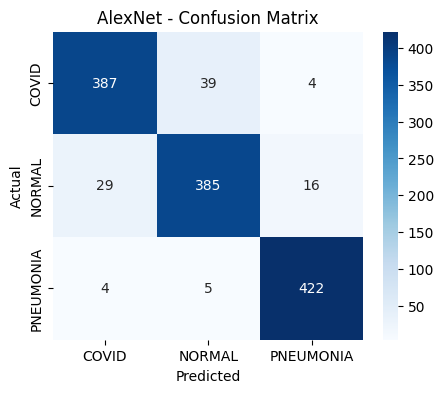

In [ ]:
class_names = list(label_encoder.classes_)

history_alexnet = alexnet_model.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_alexnet, "AlexNet")
alexnet_test_acc = evaluate_model(alexnet_model, "AlexNet")

results.append({
    "model": "AlexNet",
    "test_accuracy": alexnet_test_acc,
    "learning_rate": 1e-4,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_alexnet.history["loss"])
})

## VGG16

VGG16 is a deep convolutional neural network with a large number of parameters and a simple, uniform architecture based on stacked 3×3 convolutional layers. In this project, VGG16 was used with pretrained ImageNet weights and a custom classification head, while the convolutional base was kept frozen during training. The model was trained using the Adam optimizer with a learning rate of 1e-4.

During training, VGG16 showed gradual improvement in validation accuracy, reaching 0.7668, while validation loss remained relatively high (0.7304). On the test set, it achieved an accuracy of 0.7134, which is significantly lower than the top-performing models.

This weaker performance can be explained by the model’s large size and limited adaptation. Because the pretrained layers were frozen, the model could not fully adjust to chest X-ray features, which differ from natural images. At the same time, VGG16 has many parameters, making it harder to train effectively on a relatively small dataset. As a result, it neither adapts well nor trains efficiently, leading to lower overall performance.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

def build_vgg16_transfer():
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    base_model.trainable = False

    inputs = layers.Input(shape=INPUT_SHAPE)

    # Convert from 0-1 back to 0-255, then apply VGG16 preprocessing
    x = layers.Lambda(lambda z: vgg16_preprocess(z * 255.0))(inputs)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

vgg16_model, vgg16_base = build_vgg16_transfer()
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 38s 371ms/step - accuracy: 0.4350 - loss: 3.2042 - val_accuracy: 0.6812 - val_loss: 1.0598 - learning_rate: 1.0000e-04
Epoch 2/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.5873 - loss: 1.8879 - val_accuracy: 0.7304 - val_loss: 0.8811 - learning_rate: 1.0000e-04
Epoch 3/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.6279 - loss: 1.5640 - val_accuracy: 0.7668 - val_loss: 0.7304 - learning_rate: 5.0000e-05


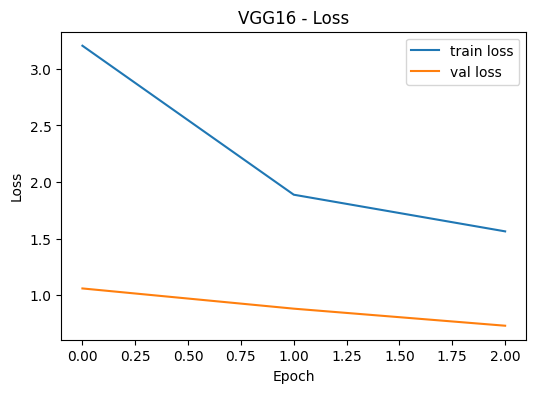

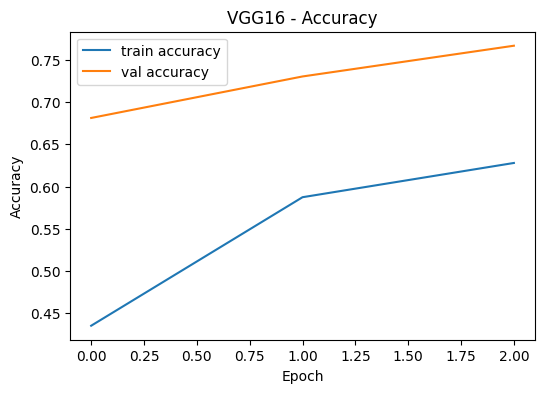


VGG16 test accuracy: 0.7134

Classification report:
              precision    recall  f1-score   support

       COVID       0.88      0.39      0.54       430
      NORMAL       0.57      0.82      0.67       430
   PNEUMONIA       0.83      0.94      0.88       431

    accuracy                           0.71      1291
   macro avg       0.76      0.71      0.70      1291
weighted avg       0.76      0.71      0.70      1291



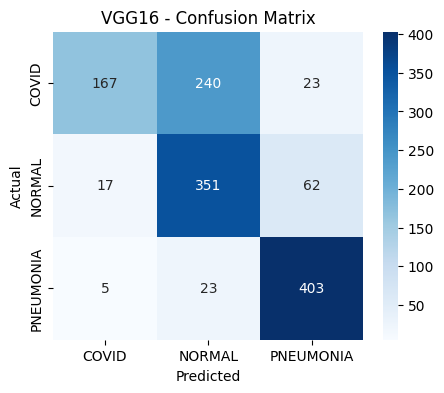

In [ ]:
history_vgg16 = vgg16_model.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_vgg16, "VGG16")
vgg16_test_acc = evaluate_model(vgg16_model, "VGG16")

results.append({
    "model": "VGG16",
    "test_accuracy": vgg16_test_acc,
    "learning_rate": 1e-4,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_vgg16.history["loss"]),
    "optimizer": "Adam"
})

### LeNet

LeNet is a shallow convolutional neural network originally designed for simple image classification tasks such as handwritten digit recognition. It consists of a small number of convolutional and pooling layers followed by fully connected layers. In this project, LeNet was trained from scratch using the Adam optimizer with a learning rate of 1e-4.

During training, LeNet showed steady but limited improvement. Validation accuracy increased to 0.7832, while validation loss decreased to 0.4694. On the test set, the model achieved an accuracy of 0.7057, which is lower than both the baseline CNN and more advanced architectures.

The main limitation of LeNet is its low capacity. Its shallow architecture makes it insufficient for capturing complex patterns in medical images such as chest X-rays. While it trains quickly and is computationally efficient, it lacks the depth needed to extract detailed spatial features. As a result, it underfits the data and achieves weaker performance compared to deeper models.

In [ ]:
# LeNet-style CNN
def build_lenet():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(6, (5, 5), activation="relu", padding="same"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Conv2D(16, (5, 5), activation="relu"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(120, activation="relu"),
        layers.Dense(84, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lenet_model = build_lenet()
lenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 192, 192, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 96, 96, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 92, 92, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 46, 46, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │     4,062,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,076,131 (15.55 MB)

 Trainable params: 4,076,131 (15.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.6794 - loss: 0.6799 - val_accuracy: 0.6976 - val_loss: 0.6490 - learning_rate: 1.0000e-04
Epoch 2/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7611 - loss: 0.5186 - val_accuracy: 0.7723 - val_loss: 0.4901 - learning_rate: 1.0000e-04
Epoch 3/12
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8007 - loss: 0.4660 - val_accuracy: 0.7832 - val_loss: 0.4694 - learning_rate: 5.0000e-05


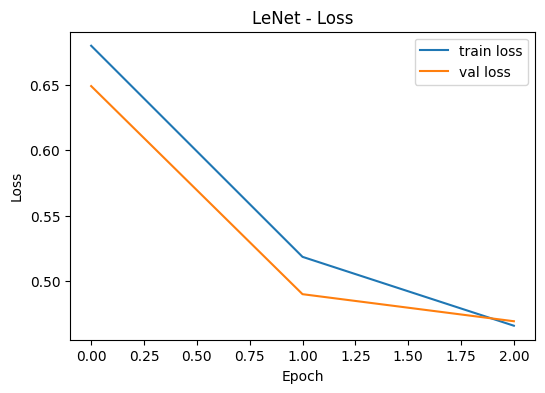

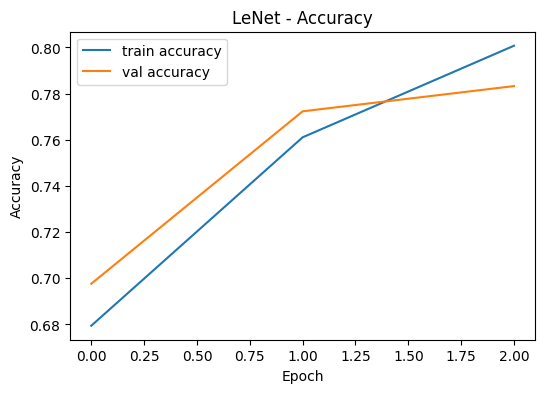


LeNet test accuracy: 0.7057

Classification report:
              precision    recall  f1-score   support

       COVID       0.58      0.89      0.70       430
      NORMAL       0.79      0.48      0.60       430
   PNEUMONIA       0.88      0.75      0.81       431

    accuracy                           0.71      1291
   macro avg       0.75      0.71      0.70      1291
weighted avg       0.75      0.71      0.70      1291



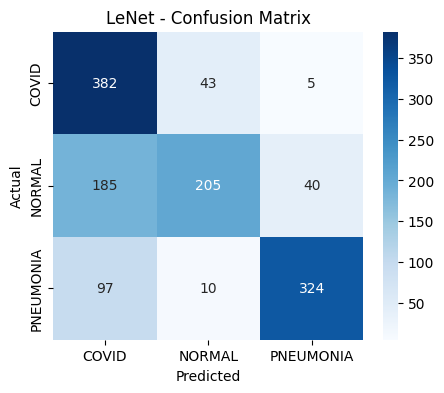

In [ ]:
class_names = list(label_encoder.classes_)

history_lenet = lenet_model.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_lenet, "LeNet")
lenet_test_acc = evaluate_model(lenet_model, "LeNet")

results.append({
    "model": "LeNet",
    "test_accuracy": lenet_test_acc,
    "learning_rate": 1e-4,
    "batch_size": BATCH_SIZE,
    "epochs_trained": len(history_lenet.history["loss"]),
    "optimizer": "Adam"
})

### Performance Comparison



All models were evaluated on the same test set, which allows a fair comparison of performance. The results show clear differences in both accuracy and generalization across architectures.

The fine-tuned ResNet50 achieved the best performance, with a test accuracy of 0.9427, the highest validation accuracy (0.9454), and the lowest validation loss (0.1546). This indicates strong generalization and stable convergence. The model benefits from pretrained ImageNet features and further improves through fine-tuning, which allows it to adapt to domain-specific patterns in chest X-ray images.

AlexNet is the second-best model, with a test accuracy of 0.9249. It shows strong learning capacity and eventually reaches high validation accuracy (0.9199), although its early training is less stable. Compared to ResNet50 Fine-Tuned, it lacks pretrained features but compensates with a deeper custom architecture.

The baseline CNN achieves moderate performance (test accuracy 0.8009). It learns quickly and reaches a validation accuracy of 0.8889 but plateaus early. This suggests limited capacity to capture more complex image patterns.

The transfer-only ResNet50 performs poorly (0.6677 test accuracy). Although it uses pretrained features, freezing the backbone prevents adaptation to medical images. Its higher validation loss (0.5274) indicates underfitting.

VGG16 and LeNet both underperform. VGG16 has relatively high loss (0.7304), likely due to its large number of parameters and inefficient learning on this dataset. LeNet, being shallow, lacks the capacity to model complex features and stabilizes at lower accuracy.

Across models, learning rate plays a key role. The baseline CNN uses a higher learning rate (1e-3) and converges quickly but less precisely. Deeper and pretrained models use lower learning rates (1e-4 to 1e-5), which leads to slower but more stable optimization. Fine-tuning with a very small learning rate (1e-5) is especially effective for adapting pretrained models.

Training curves support these conclusions. The fine-tuned ResNet50 shows steady improvement in validation accuracy and consistent reduction in validation loss. AlexNet improves rapidly after initial instability. Simpler models plateau early, while the transfer-only ResNet50 shows limited improvement.

Overall, the results show that combining pretrained features with fine-tuning produces the best performance, while models that either lack capacity or fail to adapt to the data perform worse.



In [ ]:
results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False)
results_df

,model,test_accuracy,learning_rate,batch_size,epochs_trained,optimizer
0,AlexNet,0.924864,0.0001,32,12,NaN
3,Baseline CNN,0.800930,0.0010,32,3,NaN
1,VGG16,0.713400,0.0001,32,3,Adam
2,LeNet,0.705655,0.0001,32,3,Adam
4,ResNet50 Transfer,0.667699,0.0001,32,3,NaN


In [ ]:
# recorded test accuracies
baseline_test_acc = 0.8009
resnet_test_acc = 0.6677
resnet_ft_test_acc = 0.9427
alexnet_test_acc = 0.9249
vgg16_test_acc = 0.7134
lenet_test_acc = 0.7057

results = [
    {"model": "Baseline CNN", "test_accuracy": baseline_test_acc, "learning_rate": 1e-3, "batch_size": 32, "optimizer": "Adam"},
    {"model": "ResNet50 Transfer", "test_accuracy": resnet_test_acc, "learning_rate": 1e-4, "batch_size": 32, "optimizer": "Adam"},
    {"model": "ResNet50 Fine-Tuned", "test_accuracy": resnet_ft_test_acc, "learning_rate": 1e-5, "batch_size": 32, "optimizer": "Adam"},
    {"model": "AlexNet", "test_accuracy": alexnet_test_acc, "learning_rate": 1e-4, "batch_size": 32, "optimizer": "Adam"},
    {"model": "VGG16", "test_accuracy": vgg16_test_acc, "learning_rate": 1e-4, "batch_size": 32, "optimizer": "Adam"},
    {"model": "LeNet", "test_accuracy": lenet_test_acc, "learning_rate": 1e-4, "batch_size": 32, "optimizer": "Adam"}
]

results_df = pd.DataFrame(results).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
results_df

,model,test_accuracy,learning_rate,batch_size,optimizer
0,ResNet50 Fine-Tuned,0.9427,0.00001,32,Adam
1,AlexNet,0.9249,0.00010,32,Adam
2,Baseline CNN,0.8009,0.00100,32,Adam
3,VGG16,0.7134,0.00010,32,Adam
4,LeNet,0.7057,0.00010,32,Adam
5,ResNet50 Transfer,0.6677,0.00010,32,Adam


In [ ]:
best_model = results_df.iloc[0]

print("Best Performing Model:")
print(f"Model: {best_model['model']}")
print(f"Test Accuracy: {best_model['test_accuracy']:.4f}")

Best Performing Model:
Model: ResNet50 Fine-Tuned
Test Accuracy: 0.9427


In [ ]:
summary_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "ResNet50 Transfer",
        "ResNet50 Fine-Tuned",
        "AlexNet",
        "VGG16",
        "LeNet"
    ],

    # final validation metrics (last epoch)
    "Final Val Accuracy": [0.8889, 0.7978, 0.9454, 0.9199, 0.7668, 0.7832],
    "Final Val Loss": [0.3172, 0.5274, 0.1546, 0.2388, 0.7304, 0.4694],

    # test performance
    "Test Accuracy": [0.8009, 0.6677, 0.9427, 0.9249, 0.7134, 0.7057],

    # simple training summary
    "Epochs Trained": [3, 3, 6, 12, 3, 3],
    "Learning Rate": ["1e-3", "1e-4", "1e-5", "1e-4", "1e-4", "1e-4"]
})

summary_df = summary_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

summary_df

,Model,Final Val Accuracy,Final Val Loss,Test Accuracy,Epochs Trained,Learning Rate
0,ResNet50 Fine-Tuned,0.9454,0.1546,0.9427,6,1e-5
1,AlexNet,0.9199,0.2388,0.9249,12,1e-4
2,Baseline CNN,0.8889,0.3172,0.8009,3,1e-3
3,VGG16,0.7668,0.7304,0.7134,3,1e-4
4,LeNet,0.7832,0.4694,0.7057,3,1e-4
5,ResNet50 Transfer,0.7978,0.5274,0.6677,3,1e-4


Because early stopping ended some models earlier than others, the curves have different lengths.

Early stopping was used to prevent overfitting and improve generalization. During training, models often continue to improve on the training data even after their performance on validation data stops improving. This leads to overfitting, where the model learns noise rather than meaningful patterns. Early stopping monitors validation loss and stops training when it no longer decreases for several consecutive epochs. In this project, it allowed models to stop training once they reached their optimal point, avoiding unnecessary computation and preventing performance degradation on unseen data.

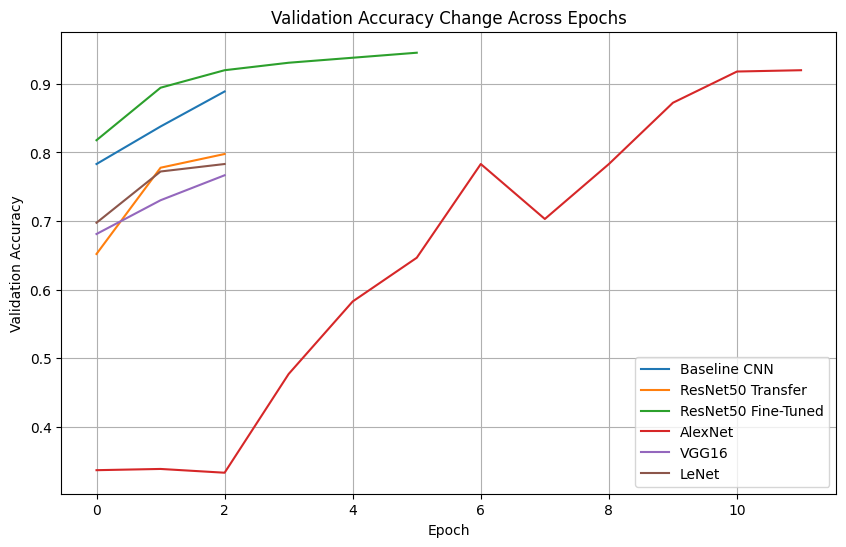

In [ ]:
# Model Comparison
history_data = {
    "Baseline CNN": {
        "val_acc": [0.7832, 0.8379, 0.8889],
        "val_loss": [0.5472, 0.4361, 0.3172]
    },
    "ResNet50 Transfer": {
        "val_acc": [0.6521, 0.7778, 0.7978],
        "val_loss": [0.7820, 0.5788, 0.5274]
    },
    "ResNet50 Fine-Tuned": {
        "val_acc": [0.8179, 0.8944, 0.9199, 0.9308, 0.9381, 0.9454],
        "val_loss": [0.4582, 0.2670, 0.2093, 0.1799, 0.1640, 0.1546]
    },
    "AlexNet": {
        "val_acc": [0.3370, 0.3388, 0.3333, 0.4772, 0.5829, 0.6466, 0.7832, 0.7031, 0.7832, 0.8725, 0.9180, 0.9199],
        "val_loss": [1.0771, 1.0674, 1.1955, 1.0385, 0.8509, 0.7894, 0.5046, 0.6886, 0.5979, 0.3091, 0.2120, 0.2388]
    },
    "VGG16": {
        "val_acc": [0.6812, 0.7304, 0.7668],
        "val_loss": [1.0598, 0.8811, 0.7304]
    },
    "LeNet": {
        "val_acc": [0.6976, 0.7723, 0.7832],
        "val_loss": [0.6490, 0.4901, 0.4694]
    }
}

plt.figure(figsize=(10,6))

for model, hist in history_data.items():
    plt.plot(hist["val_acc"], label=model)

plt.title("Validation Accuracy Change Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


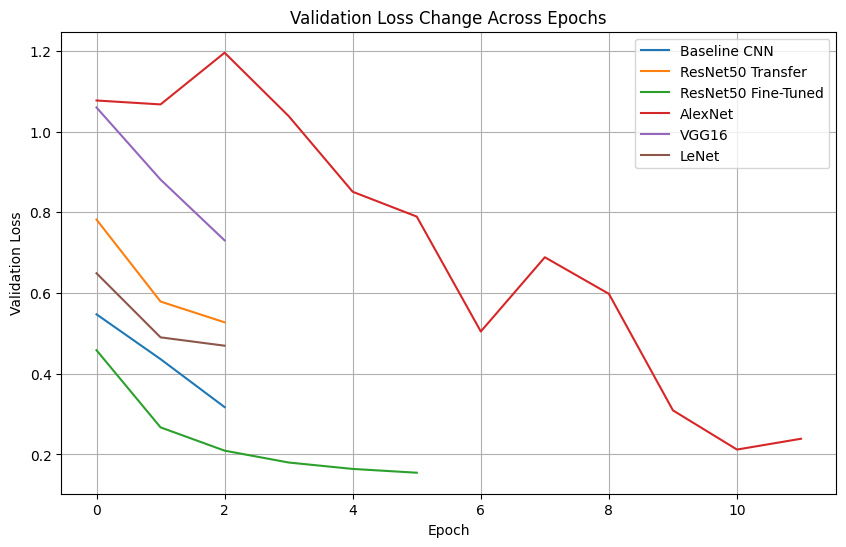

In [ ]:
plt.figure(figsize=(10,6))

for model, hist in history_data.items():
    plt.plot(hist["val_loss"], label=model)

plt.title("Validation Loss Change Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Augmentation Experiment
Augmentation is applied to the baseline CNN to evaluate its effect on generalization performance.

Epoch 1/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6311 - loss: 0.7944 - val_accuracy: 0.7067 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 2/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7259 - loss: 0.5834 - val_accuracy: 0.7523 - val_loss: 0.5206 - learning_rate: 0.0010
Epoch 3/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7693 - loss: 0.5194 - val_accuracy: 0.8124 - val_loss: 0.4421 - learning_rate: 0.0010
Epoch 4/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7980 - loss: 0.4673 - val_accuracy: 0.8288 - val_loss: 0.4128 - learning_rate: 0.0010
Epoch 5/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7957 - loss: 0.4635 - val_accuracy: 0.7796 - val_loss: 0.4653 - learning_rate: 0.0010
Epoch 6/6
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8194 - loss: 0.4170 - val_accuracy: 0.8506 - val_loss: 0.3850 - learning_rate: 0.0010


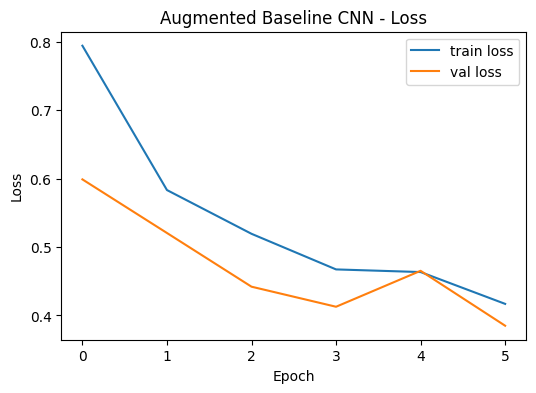

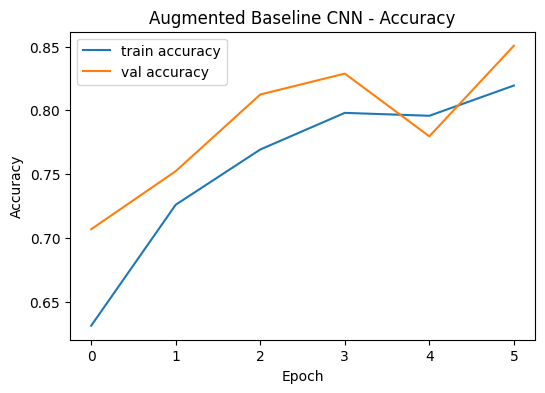


Augmented Baseline CNN test accuracy: 0.8497

Classification report:
              precision    recall  f1-score   support

       COVID       0.78      0.85      0.81       430
      NORMAL       0.83      0.74      0.79       430
   PNEUMONIA       0.94      0.95      0.95       431

    accuracy                           0.85      1291
   macro avg       0.85      0.85      0.85      1291
weighted avg       0.85      0.85      0.85      1291



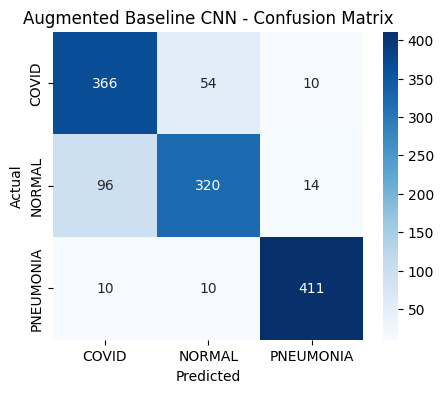

In [ ]:
# Augmentation + same optimizer scale as the original baseline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02)
])

def build_augmented_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

aug_cnn = build_augmented_baseline_cnn()

history_aug = aug_cnn.fit(
    X_train_final,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=6,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_history(history_aug, "Augmented Baseline CNN")

class_names = list(label_encoder.classes_)
aug_test_acc = evaluate_model(aug_cnn, "Augmented Baseline CNN")

Data augmentation was applied to the baseline CNN to increase variability in the training data and improve generalization. The augmentations used were horizontal flipping and small random rotations. Horizontal flipping introduces left–right variations in the images, while rotation (limited to a small angle) simulates slight differences in patient positioning during X-ray capture. These transformations were intentionally kept mild to avoid distorting medically relevant features.

The effect of augmentation was positive. The test accuracy improved from 0.8009 for the original baseline CNN to 0.8497 for the augmented model, indicating better generalization to unseen data. Although the final validation accuracy of the augmented model (0.8506) was slightly lower than that of the original baseline (0.8889), the higher test accuracy suggests that augmentation reduced overfitting and helped the model learn more robust patterns.

The results show that simple augmentation techniques can improve performance when applied carefully. However, the augmented CNN still did not outperform more advanced models such as the fine-tuned ResNet50, which achieved the highest accuracy. This indicates that while augmentation enhances generalization, model architecture and transfer learning play a larger role in achieving top performance.

# Interpretation and practical utility

In [ ]:
# Final Summary Table
summary_df = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Augmented Baseline CNN",
        "ResNet50 Transfer",
        "ResNet50 Fine-Tuned",
        "AlexNet",
        "VGG16",
        "LeNet"
    ],
    "Final Val Accuracy": [0.8889, 0.8506, 0.7978, 0.9454, 0.9199, 0.7668, 0.7832],
    "Final Val Loss": [0.3172, 0.3850, 0.5274, 0.1546, 0.2388, 0.7304, 0.4694],
    "Test Accuracy": [0.8009, 0.8497, 0.6677, 0.9427, 0.9249, 0.7134, 0.7057],
    "Epochs Trained": [3, 6, 3, 6, 12, 3, 3],
    "Learning Rate": ["1e-3", "1e-3", "1e-4", "1e-5", "1e-4", "1e-4", "1e-4"],
    "Batch Size": [32, 32, 32, 32, 32, 32, 32],
    "Optimizer": ["Adam", "Adam", "Adam", "Adam", "Adam", "Adam", "Adam"]
}).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)


summary_df = summary_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

summary_df

,Model,Final Val Accuracy,Final Val Loss,Test Accuracy,Epochs Trained,Learning Rate,Batch Size,Optimizer
0,ResNet50 Fine-Tuned,0.9454,0.1546,0.9427,6,1e-5,32,Adam
1,AlexNet,0.9199,0.2388,0.9249,12,1e-4,32,Adam
2,Augmented Baseline CNN,0.8506,0.3850,0.8497,6,1e-3,32,Adam
3,Baseline CNN,0.8889,0.3172,0.8009,3,1e-3,32,Adam
4,VGG16,0.7668,0.7304,0.7134,3,1e-4,32,Adam
5,LeNet,0.7832,0.4694,0.7057,3,1e-4,32,Adam
6,ResNet50 Transfer,0.7978,0.5274,0.6677,3,1e-4,32,Adam


The fine-tuned ResNet50 performed best among all models. It achieved the highest test accuracy (0.9427), the highest final validation accuracy (0.9454), and the lowest validation loss (0.1546). These results show that it generalized better than the other architectures. The training curves also support this conclusion: validation accuracy increased steadily across epochs, while validation loss decreased consistently without the instability seen in weaker models. This suggests that the model learned useful features efficiently and adapted well to the dataset.

The main reason for this strong performance is that fine-tuned ResNet50 combines two advantages. First, it starts with pretrained image features learned from a large dataset, which gives it a strong foundation for detecting edges, textures, and spatial patterns. Second, fine-tuning allows the model to adapt those features to chest X-ray images, which is essential because medical images differ substantially from natural images. In contrast, the transfer-only ResNet50 underperformed because freezing the pretrained backbone limited its ability to adjust to the medical domain. AlexNet also performed well, but it still fell short of the fine-tuned ResNet50, while simpler models such as the baseline CNN and LeNet had lower accuracy and weaker generalization.

The practical utility of the best-performing model is clear. A fine-tuned ResNet50 could be used as a clinical decision-support tool for chest X-ray screening. Radiologists and hospital staff would benefit most, especially in settings where fast preliminary review is needed. The model could help identify likely COVID-19 or pneumonia cases, flag suspicious scans for priority review, and reduce workload during periods of high patient volume. It could also be useful in clinics or regions with limited access to experienced imaging specialists, where automated support may improve efficiency.

This solution would be most useful in real-world scenarios that require rapid screening rather than final diagnosis. For example, hospitals managing large numbers of respiratory cases, emergency departments triaging incoming patients, and healthcare systems in resource-limited settings could all benefit from a model that highlights abnormal chest X-rays quickly. However, the model should not replace clinical judgment. False negatives and dataset-specific biases remain important risks, so the system is best viewed as an assistive tool that supports faster and more consistent review rather than a standalone diagnostic system.